# 📈 Apple Stock Market Analysis — Exploratory Data Analysis

## 📌 Project Overview

This project presents an Exploratory Data Analysis (EDA) of historical **Apple Inc. (AAPL)** stock market data.

The analysis focuses on understanding Apple's stock price movements, trading volume, daily returns, and major price changes over time.

Using Python, NumPy, Pandas, and Matplotlib, the project transforms historical stock market data into meaningful and easy-to-understand insights.

The analysis follows a beginner-friendly approach, focusing on descriptive analysis and visualization rather than advanced financial modeling.

## 🎯 Project Objectives

The main objectives of this project are to:

- Analyze Apple's historical stock price trends.
- Understand changes in opening and closing prices.
- Identify the highest and lowest stock prices.
- Analyze trading volume patterns.
- Calculate daily stock returns.
- Identify the largest daily gains and losses.
- Explore the relationship between trading volume and price movements.
- Generate meaningful insights from historical stock data.

## 🛠️ Tools & Technologies

### Programming Language
- Python

### Libraries
- NumPy
- Pandas
- Matplotlib

### Platform
- Kaggle Notebook

### Analysis Type
- Exploratory Data Analysis (EDA)

In [4]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Required libraries imported!')

Required libraries imported!


In [5]:
# Load Dataset for Analysis

df = pd.read_csv('/kaggle/input/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs/Stocks/aapl.us.txt')

print('Successfully loaded the Datset')

Successfully loaded the Datset


In [6]:
df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0


## 📂 Dataset Overview

The dataset is part of Kaggle's **Huge Stock Market Dataset**, which contains historical price and volume information for numerous U.S. stocks and ETFs.

For this project, we focus specifically on **Apple Inc. (AAPL)**.

The AAPL dataset contains daily historical market information such as:

| Column | Description |
|---|---|
| Date | Trading date |
| Open | Opening stock price |
| High | Highest price during the trading day |
| Low | Lowest price during the trading day |
| Close | Closing stock price |
| Volume | Number of shares traded |
| OpenInt | Open interest |

The dataset allows us to study Apple's historical stock performance using exploratory data analysis.

In [7]:
df.shape

(8364, 7)

In [8]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     8364 non-null   object 
 1   Open     8364 non-null   float64
 2   High     8364 non-null   float64
 3   Low      8364 non-null   float64
 4   Close    8364 non-null   float64
 5   Volume   8364 non-null   int64  
 6   OpenInt  8364 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 457.5+ KB


In [10]:
df.isnull().sum()

Date       0
Open       0
High       0
Low        0
Close      0
Volume     0
OpenInt    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,Open,High,Low,Close,Volume,OpenInt
count,8364.000000,8364.000000,8364.000000,8364.000000,8.364000e+03,8364.0
mean,22.284350,22.495867,22.054244,22.281018,1.066416e+08,0.0
std,37.763402,38.057733,37.447432,37.764469,9.935187e+07,0.0
min,0.233050,0.235640,0.230510,0.230510,0.000000e+00,0.0
25%,1.137100,1.164200,1.112800,1.137100,4.384365e+07,0.0
50%,1.632800,1.663400,1.600600,1.628250,7.481383e+07,0.0
75%,23.739000,23.930500,23.335750,23.694500,1.320534e+08,0.0
max,175.110000,175.610000,174.270000,175.610000,2.069770e+09,0.0


# 🧹 Data Cleaning & Preparation

Before beginning the exploratory analysis, the dataset was checked for missing values, duplicate records, incorrect data types, and columns with limited analytical value.

### Data Quality Findings

- The dataset contains **8,364 records** and **7 columns**.
- There are **no missing values**.
- There are **no duplicate records**.
- The `Date` column is stored as an object and needs to be converted into datetime format.
- The `OpenInt` column contains only zero values and therefore does not provide useful information for this analysis.

### Cleaning Steps

1. Convert `Date` to datetime format.
2. Remove the `OpenInt` column because it contains no meaningful variation.
3. Verify the cleaned dataset before starting the exploratory analysis.

In [13]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[ns]')

In [14]:
df.dtypes

Date       datetime64[ns]
Open              float64
High              float64
Low               float64
Close             float64
Volume              int64
OpenInt             int64
dtype: object

In [15]:
df = df.drop(columns = 'OpenInt')

In [16]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062


In [17]:
df.shape

(8364, 6)

In [18]:
print('Null Values :',df.isnull().sum())

print('Duplicate Values:',df.duplicated().sum())

Null Values : Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Duplicate Values: 0


## 📊 Feature Creation

To analyze daily stock performance, a new `Daily_Return` column is created.

Daily return measures the percentage change in the closing price compared with the previous trading day's closing price.

This metric will help us identify periods of positive and negative price movement.

$$
Daily\ Return = \frac{Today's\ Close - Previous\ Close}{Previous\ Close} \times 100
$$

In [19]:
df['Daily_Return'] = df['Close'].pct_change() * 100 

In [20]:
df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,NaN
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,-0.599226
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,1.822756
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,-2.992867
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,5.548080


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8364 entries, 0 to 8363
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          8364 non-null   datetime64[ns]
 1   Open          8364 non-null   float64       
 2   High          8364 non-null   float64       
 3   Low           8364 non-null   float64       
 4   Close         8364 non-null   float64       
 5   Volume        8364 non-null   int64         
 6   Daily_Return  8363 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 457.5 KB


In [22]:
df.describe()

,Date,Open,High,Low,Close,Volume,Daily_Return
count,8364,8364.000000,8364.000000,8364.000000,8364.000000,8.364000e+03,8363.000000
mean,2001-04-04 07:55:00.430416,22.284350,22.495867,22.054244,22.281018,1.066416e+08,0.113072
min,1984-09-07 00:00:00,0.233050,0.235640,0.230510,0.230510,0.000000e+00,-51.846338
25%,1992-12-13 06:00:00,1.137100,1.164200,1.112800,1.137100,4.384365e+07,-1.316933
50%,2001-03-27 12:00:00,1.632800,1.663400,1.600600,1.628250,7.481383e+07,0.000000
75%,2009-07-24 18:00:00,23.739000,23.930500,23.335750,23.694500,1.320534e+08,1.478185
max,2017-11-10 00:00:00,175.110000,175.610000,174.270000,175.610000,2.069770e+09,33.212140
std,NaN,37.763402,38.057733,37.447432,37.764469,9.935187e+07,2.837324


In [23]:
df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].head()

,Date,Open,High,Low,Close,Volume,Daily_Return
0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,NaN
1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,-0.599226
2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,1.822756
3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,-2.992867
4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,5.548080


## 📅 Q1. How has Apple's Closing Price Changed Over Time?

The first step is to understand Apple's long-term stock price trend.

By analyzing the daily closing price over time, we can identify periods of growth, decline, and major changes in Apple's stock valuation.

In [25]:
start_price = df.iloc[0]['Close']
end_price = df.iloc[-1]['Close']

print("Starting Closing Price:", start_price)
print("Ending Closing Price:", end_price)

Starting Closing Price: 0.42388
Ending Closing Price: 174.67


In [26]:
price_change = ((end_price - start_price) / start_price) * 100

print("Overall Price Change:", round(price_change, 2), "%")

Overall Price Change: 41107.42 %


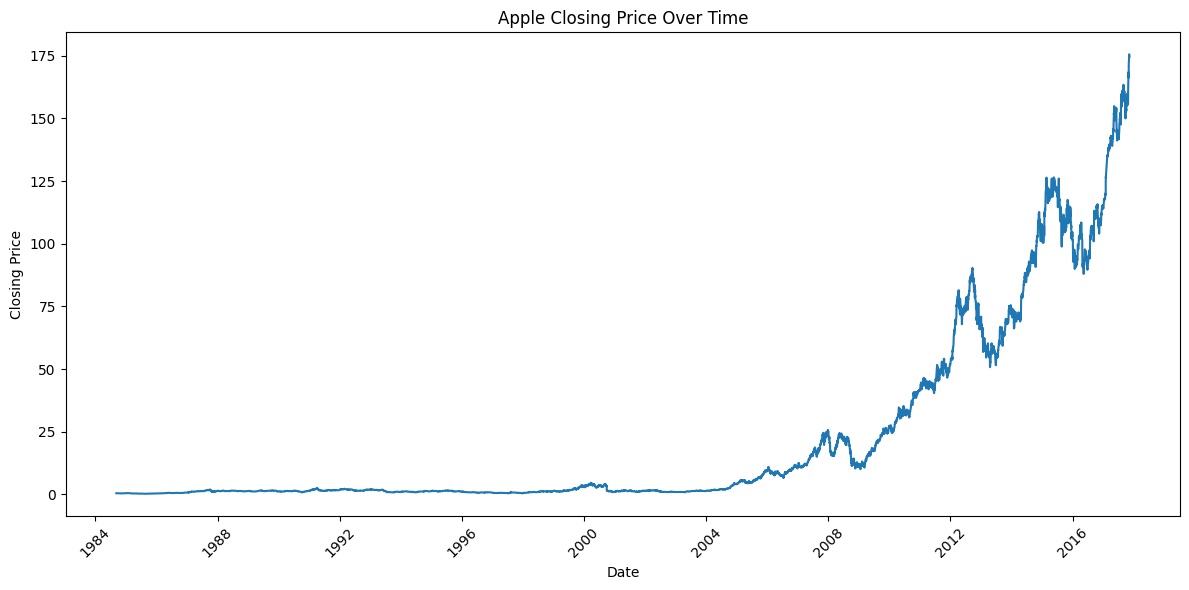

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Close'])

plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🔑 Key Insight

Apple's closing price increased from **$0.42388** in September 1984 to **$174.67** in November 2017, representing an overall increase of approximately **41,107.42%**.

The long-term trend shows substantial growth in Apple's stock price over the period covered by the dataset.

> Note: This percentage reflects the change between the first and last observations in this historical dataset. It should not be interpreted as an annualized return.

## 💰 Q2. What Are Apple's Highest and Lowest Closing Prices?

Identifying the highest and lowest closing prices helps us understand the range of Apple's historical stock valuation.

This analysis will also identify the dates on which these extreme closing prices occurred.

In [28]:
highest_close = df.loc[df['Close'].idxmax()]

print("Highest Closing Price:", highest_close['Close'])
print("Date:", highest_close['Date'])

Highest Closing Price: 175.61
Date: 2017-11-08 00:00:00


In [29]:
lowest_close = df.loc[df['Close'].idxmin()]

print("Lowest Closing Price:", lowest_close['Close'])
print("Date:", lowest_close['Date'])

Lowest Closing Price: 0.23051
Date: 1985-08-15 00:00:00


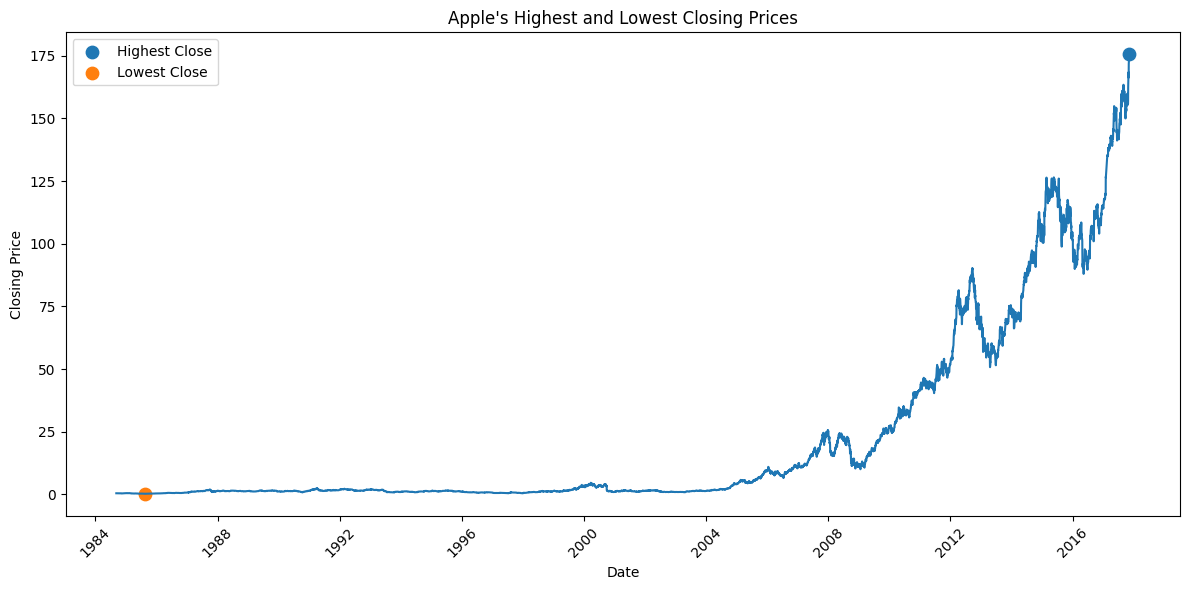

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Close'])

plt.scatter(highest_close['Date'], highest_close['Close'], s=80, label='Highest Close')
plt.scatter(lowest_close['Date'], lowest_close['Close'], s=80, label='Lowest Close')

plt.title("Apple's Highest and Lowest Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🔑 Key Insight

Apple's highest closing price in the dataset was **$175.61**, recorded on **November 8, 2017**.

The lowest closing price was **$0.23051**, recorded on **August 15, 1985**.

The substantial difference between these two values highlights Apple's significant long-term increase in stock price over the period analyzed.

## 📊 Q3. How Has Trading Volume Changed Over Time?

Trading volume represents the number of shares traded during a trading day.

Analyzing volume over time helps us understand periods of unusually high or low market activity and identify days when investor participation was particularly strong.

In [31]:
highest_volume = df.loc[df['Volume'].idxmax()]

print("Highest Trading Volume:", highest_volume['Volume'])
print("Date:", highest_volume['Date'])

Highest Trading Volume: 2069769775
Date: 2000-09-29 00:00:00


In [32]:
average_volume = df['Volume'].mean()

print("Average Trading Volume:", round(average_volume))

Average Trading Volume: 106641628


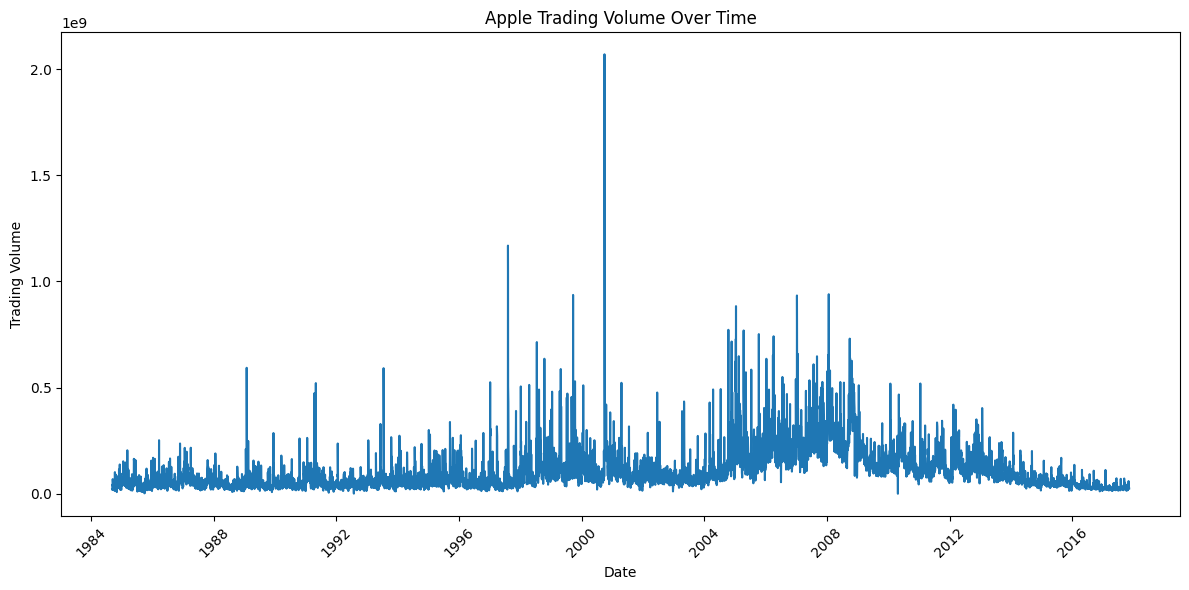

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Volume'])

plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
top_volume_days = df.nlargest(5, 'Volume')[['Date', 'Volume', 'Close']]

top_volume_days

,Date,Volume,Close
4059,2000-09-29,2069769775,1.6496
3265,1997-08-06,1168653844,0.8427
3266,1997-08-07,1047328117,0.9334
5893,2008-01-23,939695278,17.8100
3800,1999-09-21,936366131,2.2167


### 🔑 Key Insight

Apple's average daily trading volume during the analyzed period was approximately **106.64 million shares**.

The highest trading volume was recorded on **September 29, 2000**, when approximately **2.07 billion shares** were traded.

Several other unusually high-volume days occurred during 1997, 1999, and 2008, indicating periods of exceptionally high market activity.

These observations highlight that Apple's trading activity varied substantially across different periods.

## 📈 Q4. What Is Apple's Daily Return Pattern?

Daily return measures the percentage change in Apple's closing price from one trading day to the next.

Analyzing daily returns helps us understand the typical day-to-day movement of the stock and the overall distribution of positive and negative returns.

In [35]:
average_return = df['Daily_Return'].mean()

print("Average Daily Return:", round(average_return, 4), "%")

Average Daily Return: 0.1131 %


In [36]:
positive_days = (df['Daily_Return'] > 0).sum()
negative_days = (df['Daily_Return'] < 0).sum()
zero_days = (df['Daily_Return'] == 0).sum()

print("Positive Return Days:", positive_days)
print("Negative Return Days:", negative_days)
print("Zero Return Days:", zero_days)

Positive Return Days: 4141
Negative Return Days: 3915
Zero Return Days: 307


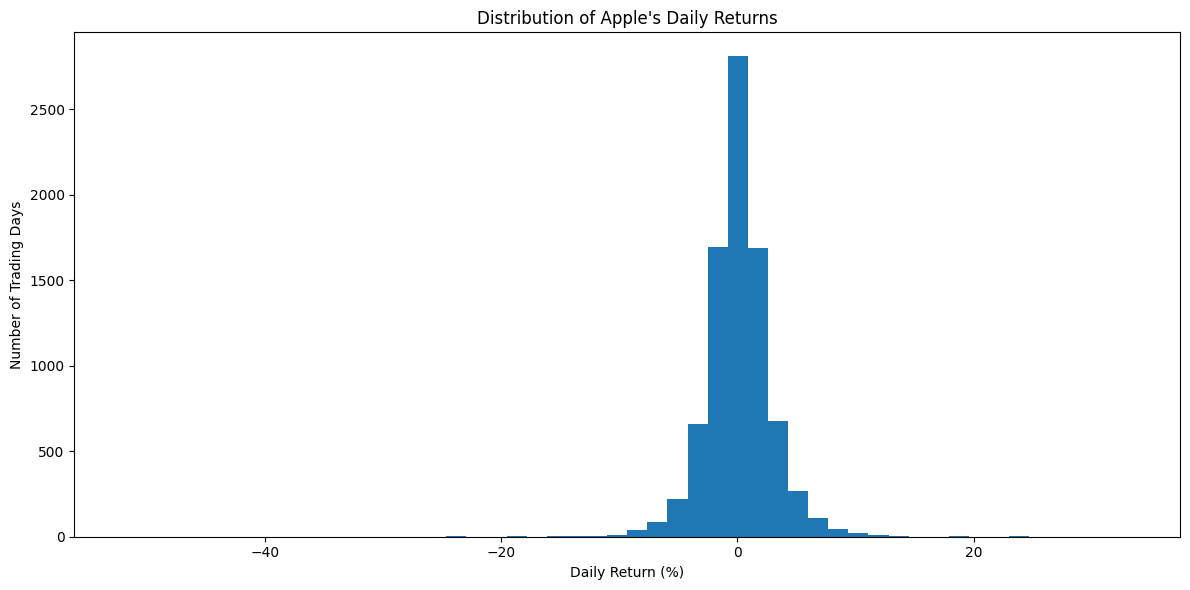

In [37]:
plt.figure(figsize=(12, 6))

plt.hist(df['Daily_Return'].dropna(), bins=50)

plt.title("Distribution of Apple's Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Number of Trading Days")

plt.tight_layout()
plt.show()

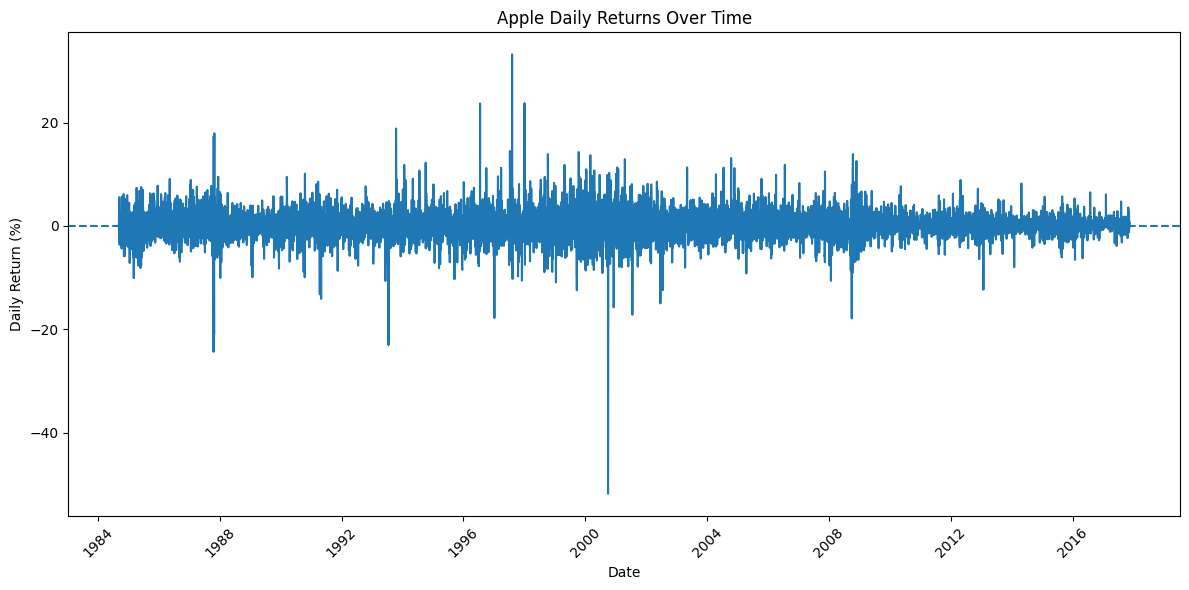

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df['Daily_Return'])

plt.axhline(0, linestyle='--')

plt.title("Apple Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 🔑 Key Insight

Apple's average daily return during the analyzed period was approximately **0.1131%**.

The stock recorded:

- **4,141 positive-return days**
- **3,915 negative-return days**
- **307 zero-return days**

Positive-return days were slightly more frequent than negative-return days, indicating a relatively balanced pattern of daily price movements with a small positive tendency over the long term.

## 🔥 Q5. What Were Apple's Largest Daily Gains and Losses?

Identifying the largest daily gains and losses helps us understand the most extreme short-term price movements in Apple's historical data.

This analysis can highlight periods of unusually high volatility.

In [39]:
largest_gain = df.loc[df['Daily_Return'].idxmax()]

print("Largest Daily Gain:", round(largest_gain['Daily_Return'], 2), "%")
print("Date:", largest_gain['Date'])
print("Closing Price:", largest_gain['Close'])

Largest Daily Gain: 33.21 %
Date: 1997-08-06 00:00:00
Closing Price: 0.8427


In [40]:
largest_loss = df.loc[df['Daily_Return'].idxmin()]

print("Largest Daily Loss:", round(largest_loss['Daily_Return'], 2), "%")
print("Date:", largest_loss['Date'])
print("Closing Price:", largest_loss['Close'])

Largest Daily Loss: -51.85 %
Date: 2000-09-29 00:00:00
Closing Price: 1.6496


In [41]:
top_gains = df.nlargest(5, 'Daily_Return')[['Date', 'Daily_Return', 'Close']]

top_losses = df.nsmallest(5, 'Daily_Return')[['Date', 'Daily_Return', 'Close']]

print("Top 5 Daily Gains:")
display(top_gains)

print("Top 5 Daily Losses:")
display(top_losses)

Top 5 Daily Gains:


,Date,Daily_Return,Close
3265,1997-08-06,33.212140,0.8427
3368,1998-01-02,23.741281,0.5198
2999,1996-07-18,23.704663,0.6685
3370,1998-01-06,19.354839,0.6068
2303,1993-10-15,18.840389,0.9039


Top 5 Daily Losses:


,Date,Daily_Return,Close
4059,2000-09-29,-51.846338,1.6496
787,1987-10-19,-24.373503,1.1679
2239,1993-07-16,-23.058782,0.8809
792,1987-10-26,-21.150295,0.8966
6066,2008-09-29,-17.914992,13.4800


### 📊 Visualization — Extreme Daily Returns

The following visualization highlights Apple's largest positive and negative daily price movements identified in the dataset.

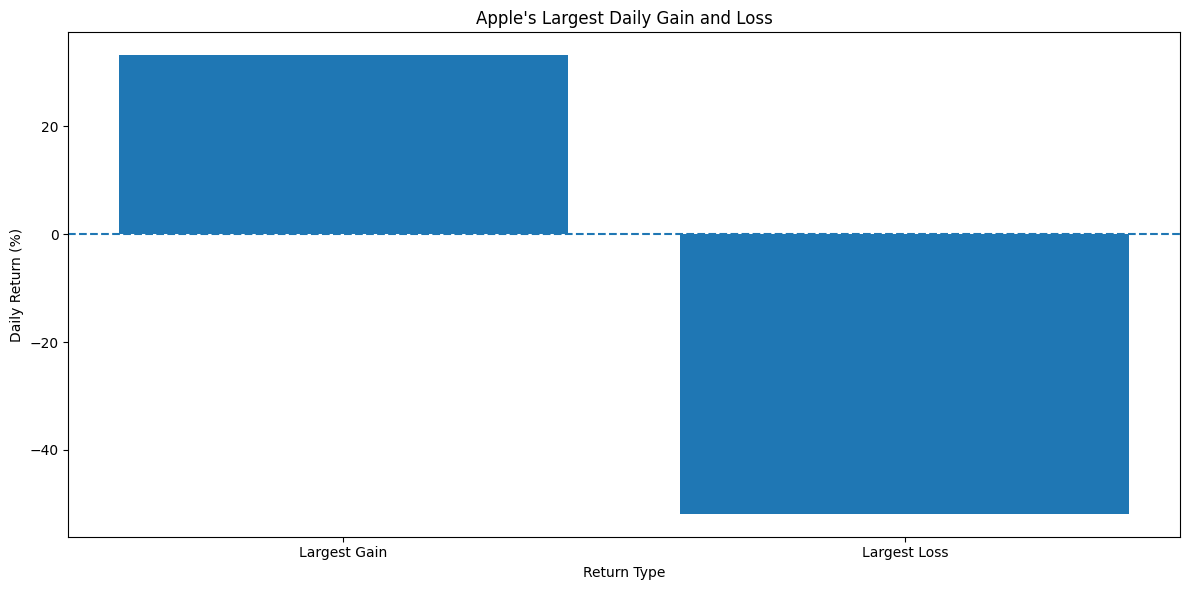

In [46]:
plt.figure(figsize=(12, 6))

plt.bar(
    ['Largest Gain', 'Largest Loss'],
    [largest_gain['Daily_Return'], largest_loss['Daily_Return']]
)

plt.axhline(0, linestyle='--')

plt.title("Apple's Largest Daily Gain and Loss")
plt.xlabel("Return Type")
plt.ylabel("Daily Return (%)")

plt.tight_layout()
plt.show()

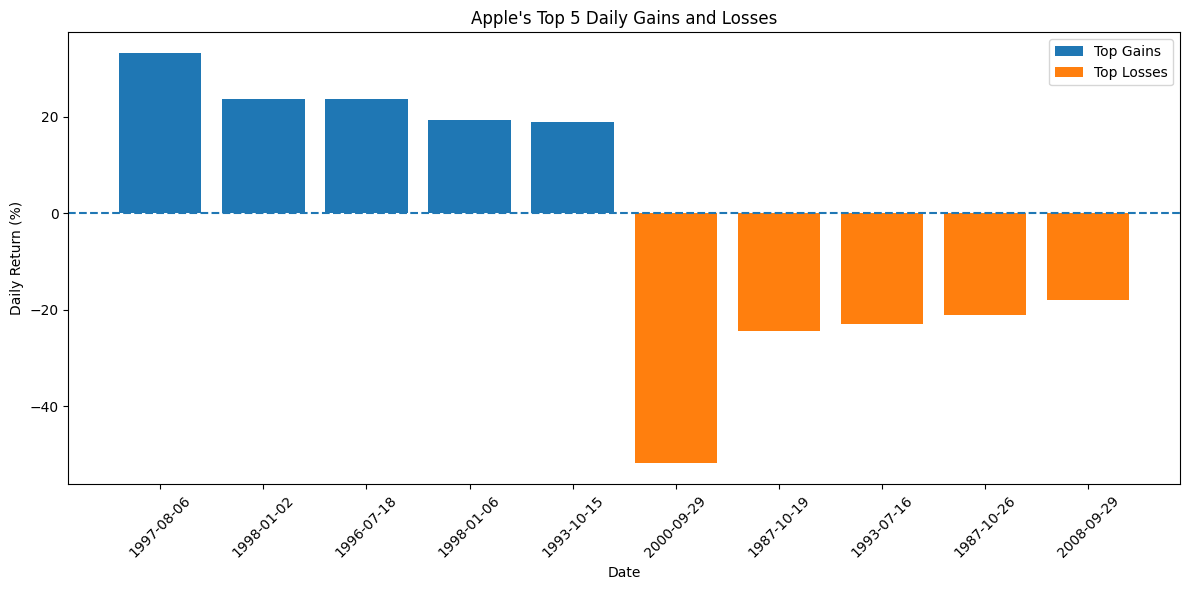

In [47]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_gains['Date'].dt.strftime('%Y-%m-%d'),
    top_gains['Daily_Return'],
    label='Top Gains'
)

plt.bar(
    top_losses['Date'].dt.strftime('%Y-%m-%d'),
    top_losses['Daily_Return'],
    label='Top Losses'
)

plt.axhline(0, linestyle='--')

plt.title("Apple's Top 5 Daily Gains and Losses")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### 🔑 Key Insight

Apple's largest daily gain in the dataset was **33.21%**, recorded on **August 6, 1997**.

The largest daily loss was **−51.85%**, recorded on **September 29, 2000**.

These extreme movements highlight periods of significant short-term volatility in Apple's historical stock performance.


## 📊 Q6. Is Higher Trading Volume Associated With Larger Price Movements?

The final analysis examines whether unusually high trading volume is associated with larger daily price movements.

Absolute daily return is used because both positive and negative price changes represent the magnitude of daily movement.

A scatter plot will be used to visually examine the relationship between trading volume and absolute daily return.

In [42]:
df['Absolute_Return'] = df['Daily_Return'].abs()

In [43]:
volume_return_corr = df['Volume'].corr(df['Absolute_Return'])

print("Correlation between Trading Volume and Absolute Daily Return:",
      round(volume_return_corr, 4))

Correlation between Trading Volume and Absolute Daily Return: 0.4194


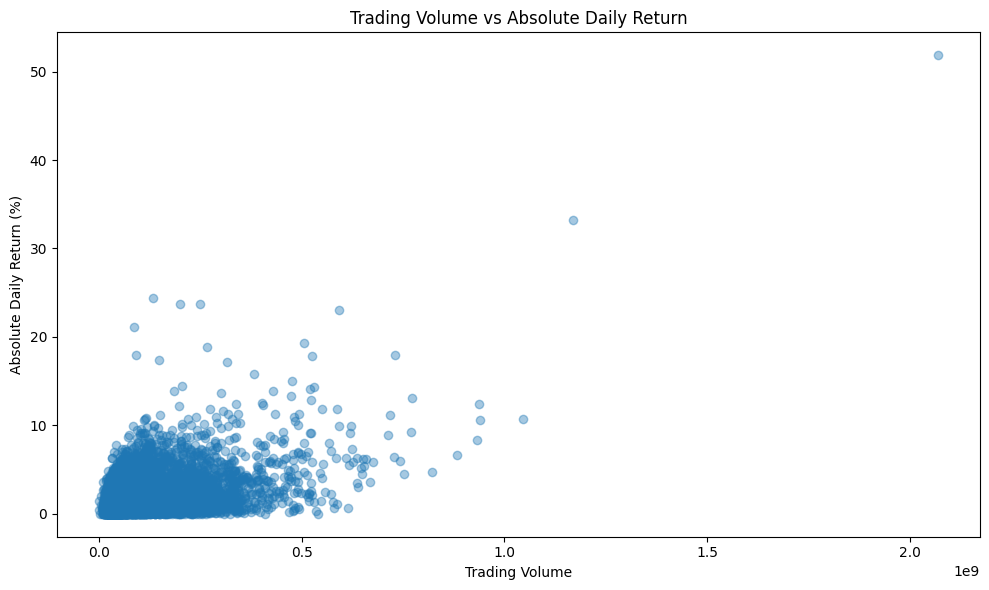

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Volume'], df['Absolute_Return'], alpha=0.4)

plt.title("Trading Volume vs Absolute Daily Return")
plt.xlabel("Trading Volume")
plt.ylabel("Absolute Daily Return (%)")

plt.tight_layout()
plt.show()

In [45]:
volume_threshold = df['Volume'].quantile(0.90)

high_volume = df[df['Volume'] >= volume_threshold]
normal_volume = df[df['Volume'] < volume_threshold]

print("High-volume threshold:", round(volume_threshold))
print("Average absolute return on high-volume days:",
      round(high_volume['Absolute_Return'].mean(), 4), "%")
print("Average absolute return on other days:",
      round(normal_volume['Absolute_Return'].mean(), 4), "%")

High-volume threshold: 225755760
Average absolute return on high-volume days: 3.6262 %
Average absolute return on other days: 1.7569 %


### 🔑 Key Insight

The correlation between trading volume and absolute daily return was **0.4194**, indicating a moderate positive relationship.

Days with trading volume of approximately **225.76 million shares or more** had an average absolute daily return of **3.6262%**, compared with **1.7569%** on other days.

Therefore, high-volume trading days were associated with substantially larger price movements in the historical AAPL dataset.

> Note: Correlation indicates association, not causation. This analysis does not establish that higher trading volume directly causes larger price movements.

# 📌 Overall Key Findings

The analysis of Apple's historical stock data produced several important findings:

1. **Long-Term Price Growth**  
   Apple's closing price increased from **$0.42388** in 1984 to **$174.67** in 2017, representing an overall increase of approximately **41,107.42%**.

2. **Historical Price Range**  
   The lowest closing price was **$0.23051** on August 15, 1985, while the highest was **$175.61** on November 8, 2017.

3. **Trading Activity**  
   Average daily trading volume was approximately **106.64 million shares**. The highest volume was approximately **2.07 billion shares** on September 29, 2000.

4. **Daily Returns**  
   The average daily return was **0.1131%**, with **4,141 positive-return days** and **3,915 negative-return days**.

5. **Extreme Price Movements**  
   The largest daily gain was **33.21%** on August 6, 1997, while the largest daily loss was **−51.85%** on September 29, 2000.

6. **Volume and Price Movement**  
   Trading volume and absolute daily return had a correlation of **0.4194**. High-volume days had an average absolute return of **3.6262%**, compared with **1.7569%** on other days.

# 💡 Business Recommendations

Based on the exploratory analysis, the following observations can support further financial analysis:

- **Monitor trading volume:** Unusually high trading volume can coincide with larger price movements and may indicate periods requiring closer attention.

- **Track daily returns:** Monitoring daily returns can help identify unusually volatile trading sessions.

- **Consider long-term trends:** The historical data demonstrates substantial long-term price growth, showing why long-term price trends can provide valuable context alongside short-term movements.

- **Investigate extreme movements:** The largest gains and losses can be studied separately to understand the events or market conditions associated with unusually large price changes.

- **Use multiple indicators:** Trading volume, price movements, and returns should be considered together rather than relying on a single metric.

> These recommendations are based on historical exploratory analysis and should not be interpreted as investment advice.

# 🏁 Conclusion

This Exploratory Data Analysis examined historical Apple (AAPL) stock market data covering **8,364 trading records from 1984 to 2017**.

The analysis explored long-term closing-price trends, historical price extremes, trading volume, daily returns, extreme price movements, and the relationship between trading activity and price movement.

The results show substantial long-term growth in Apple's historical stock price, while daily returns remained relatively balanced between positive and negative trading sessions. The analysis also found that high-volume trading days were associated with larger absolute price movements.

Overall, the project demonstrates how Python, NumPy, Pandas, and Matplotlib can be used to transform historical stock-market data into clear and meaningful business insights.

This project focuses on exploratory analysis and historical patterns rather than predicting future stock prices or providing investment recommendations.

# 📚 References

1. Kaggle — Huge Stock Market Dataset  
   https://www.kaggle.com/datasets/borismarjanovic/price-volume-data-for-all-us-stocks-etfs

2. Apple Inc. — Historical Stock Data  
   AAPL data extracted from the Kaggle Huge Stock Market Dataset.

3. Pandas Documentation  
   https://pandas.pydata.org/docs/

4. NumPy Documentation  
   https://numpy.org/doc/

5. Matplotlib Documentation  
   https://matplotlib.org/stable/contents.html